# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
Every home is unique, but pricing it accurately is more complex than it seems. This project set out to answer a straightforward business question: given what we know about a property, its size, location, age, and physical features, can we build a reliable system to estimate its tax-assessed value? Accurate valuations matter because they drive Zillow's core product, the Zestimate, which millions of buyers, sellers, and investors rely on every day to make major financial decisions.

To build this system, we worked with a dataset of nearly 78,000 residential properties across Los Angeles County, each described by more than 50 characteristics. The data reflected the complexity of real-world real estate: many properties had missing information, some fields were redundant, and a handful of extremely high-value homes skewed the picture. After careful cleaning and preparation, we focused on the features that genuinely capture what makes a home valuable, finished square footage, number of bathrooms, geographic location, lot size, building quality, and age of the home, among others.

Our analysis confirmed several intuitions that experienced real estate professionals would recognize immediately. Size matters most: larger homes consistently command higher assessed values. Location is the second most powerful driver, with ZIP code and geographic coordinates both playing significant roles. Newer, higher-quality construction also correlates strongly with higher valuations.

We tested multiple modeling approaches and found that a Random Forest model, which combines hundreds of individual decision trees to produce a more robust prediction, outperformed simpler alternatives. On properties the model had never seen before, it predicted tax-assessed values within roughly **$187,000 on average**. For a market where homes routinely sell for $400,000 to over $1 million, this represents a meaningful but improvable level of accuracy.

Our key recommendation is to adopt this model as a foundation for automated property valuation, while investing in richer location data, such as neighborhood amenities, school district ratings, and proximity to transit, which could substantially close the remaining gap between predictions and actual values. The model is already strong enough to flag properties that may be significantly over or under assessed, making it a practical tool for both internal review and customer-facing valuation services.



## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
### Topic and Context

Accurate property valuation is one of the most important, and most difficult, tasks in the real estate industry. Traditional appraisals are costly, time-consuming, and subject to human bias, while simple rule-of-thumb estimates often fail to account for the full complexity of what makes one home worth more than another. Automated Valuation Models (AVMs) have emerged as a scalable alternative, enabling platforms like Zillow to provide near-instant property estimates at scale. This project was undertaken in that spirit: to develop a data-driven regression model capable of predicting the tax-assessed value of residential properties in Los Angeles County, California.

The dataset used is a curated subset of the Zillow housing data originally featured in the 2017 Kaggle Zestimate competition. It contains detailed records on nearly 78,000 individual properties, including physical attributes, geographic identifiers, and financial assessments. The target variable is `taxvaluedollarcnt`, the total tax-assessed dollar value of each property, which serves as a proxy for market value and is central to Zillow's core valuation product.

### Problem Statement and Motivation

The core problem is that property values are driven by a wide and interacting set of factors, location, size, age, condition, amenities, and neighborhood characteristics, making manual estimation unreliable at scale. For a real estate company with a small in-house data science team, building a systematic, reproducible model from historical records offers a way to standardize valuations, reduce appraisal costs, and surface pricing anomalies that might otherwise go unnoticed. The motivation is both operational (saving time and money) and strategic (offering more accurate, trustworthy valuations to clients).

### Objectives and Goals

This analysis has three concrete objectives, distinct from the broader motivation:

1. **Explore and understand the data** : identify the most informative features, understand the distribution of property values, and document data quality issues.
2. **Build and compare regression models** : train and evaluate multiple machine learning algorithms to predict tax-assessed value, using rigorous cross-validation to measure generalization.
3. **Select and interpret the best model** : identify the top-performing model, examine its predictions on held-out data, and draw actionable conclusions for the business about what drives property value and where the model can and cannot be trusted.


## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
### Source

The dataset is a reduced version of the Zillow housing dataset originally used in the 2017 Kaggle Zestimate Prize competition. It was provided for this course via Boston University's CS505/DX603 course infrastructure and contains residential property records from Los Angeles County, California, assessed in 2016.

### Size and Structure

The raw dataset contains **77,613 observations (properties)** and **55 features (columns)**. Of those 55 columns, 49 are continuous numeric (`float64`), 5 are categorical (`object`), and 1 is an integer identifier. After cleaning, the working dataset was reduced to **77,572 rows and 20 features**.

### Variable Types

The features span several categories:

- **Physical attributes** : square footage of finished living area, lot size, number of bedrooms and bathrooms, number of rooms, garage size, year built, number of stories
- **Quality and condition** : building quality type, heating system type, air conditioning type
- **Geographic identifiers** : latitude, longitude, ZIP code, city ID, neighborhood ID, county land use code, zoning description
- **Property classification** : land use type, property county land use code
- **Financial/administrative** : tax delinquency flag, assessment year (constant across all records)

### Target Variable

The target variable is **`taxvaluedollarcnt`** : the total tax-assessed dollar value of the property (land plus structure). Values range from a few thousand dollars to over $40 million, with a median around $380,000 and a heavily right-skewed distribution driven by a small number of extremely high-value luxury properties.

### Missing Values and Data Quality Issues

Missing data was a major challenge in this dataset. Key issues included:

- **18 columns had more than 50% missing values**, including `fireplacecnt` (89% missing), `poolcnt` (79%), `garagecarcnt` (67%), and `airconditioningtypeid` (68%). These were dropped entirely.
- **Several columns were near-constant or redundant** : `assessmentyear` was 2016 for every record; `buildingclasstypeid` was 100% missing; pool type indicators had only one unique non-null value.
- **35 rows had a missing target value** and were removed.
- After dropping high-missing columns and problematic rows, **median imputation** was applied to remaining numerical gaps, and **mode imputation** was used for categorical fields.
- The target variable is highly skewed (skewness > 4), with significant outliers that could bias model training if not accounted for.


## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
Our analytical framework followed a staged pipeline from data understanding to model finalization. First, we performed exploratory analysis and cleaning in Milestone 1 to identify data quality risks (high missingness, redundant fields, skewed target, and outliers). Second, in Milestone 2, we trained a baseline set of models (Linear Regression, Ridge Regression, Random Forest) using repeated cross-validation. Third, we added engineered features and compared performance again. Fourth, we applied feature selection and then hyperparameter tuning to produce a final model.

To evaluate model behavior across settings, we used repeated cross-validation as our validation framework and tracked both mean error and fold-to-fold variability (standard deviation). This let us see the equivalent of a validation-curve trend in practice: how performance changed as we changed model complexity (for example, number of selected features and Random Forest depth/leaf settings). We also used a held-out test set for final generalization checks.

We selected **MAE as the primary metric** because it is directly interpretable in dollars, which is most meaningful for a real estate business audience ("average absolute prediction error per property"). We reported RMSE and $R^2$ as secondary metrics. RMSE was useful because it penalizes large errors more strongly, which matters for expensive outlier properties, while $R^2$ helped summarize explained variance. However, due to strong right skew in housing values, MAE provided the clearest and most stable optimization target for model comparison and final selection.

### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
The raw Zillow dataset had multiple quality issues: high missingness in several columns, a few near-constant or low-utility fields, ID-like columns with little predictive value, and a highly right-skewed target (`taxvaluedollarcnt`).

Our main preprocessing decisions were:
1. Drop unsuitable features (`parcelid`, census/administrative ID-style columns, constant-like `assessmentyear`) that were unlikely to generalize.
2. Drop features with more than 50% missing values (such as many pool/fireplace/garage-related fields), because heavy imputation there would add noise.
3. Remove samples with missing target values and a small number of rows with too many missing features.
4. Impute remaining numeric missing values with median and categorical missing values with mode.
5. Encode categorical variables so all features were model-ready, then save the cleaned dataset for reproducible modeling.

For outliers, we chose not to remove high-value homes during cleaning. These are rare but real observations in Los Angeles and part of the business problem. Instead, we acknowledged their effect on error metrics and model stability.

What worked well:
- Median imputation was robust on skewed numeric variables.
- Dropping high-missing columns improved data reliability.
- The cleaned dataset transferred smoothly into the Milestone 2 modeling pipeline.

What did not work as well:
- Keeping all extreme-value homes increased residual spread at the high end.
- Some potentially useful amenity columns were lost due to missingness thresholds, so we likely gave up some predictive signal for robustness.

### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  
Feature engineering was motivated by Milestone 1 findings that housing value relationships are nonlinear and interaction-driven. We created four additional features:

1. `sqft_squared` = (`calculatedfinishedsquarefeet`)$^2$ to capture nonlinear size effects.
2. `home_age` = 2016 - `yearbuilt` to convert raw year into an interpretable age feature.
3. `bath_sqft_interaction` = `bathroomcnt` $\times$ `calculatedfinishedsquarefeet` to model interaction between interior size and amenities.
4. `lot_living_ratio` = `lotsizesquarefeet` / `calculatedfinishedsquarefeet` to represent land-to-living-space balance.

These choices were based on domain logic (size, age, and functional utility all influence value) plus exploratory evidence from Milestone 1 (strong size-related correlations and promising polynomial transformations).

What worked:
- Linear and Ridge models improved meaningfully after feature engineering (CV MAE improved from roughly $246k to about $234k).
- Engineered terms, especially size-related nonlinear/interaction features, helped linear models represent complexity they otherwise miss.

What did not work (or was limited):
- Random Forest did not improve much with manual engineered features (its CV MAE stayed around $191k and slightly worsened in one comparison), likely because tree ensembles already learn nonlinear splits and interactions automatically.
- Ratio features appeared less consistently helpful than size and age transforms.

Overall, feature engineering was most beneficial for linear models, while tree-based models gained little additional signal.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  
We evaluated three regression models that represent different bias-variance behavior:
- **Linear Regression** as a simple, interpretable baseline.
- **Ridge Regression** as a regularized linear alternative.
- **Random Forest Regressor** as a nonlinear ensemble expected to perform well on complex tabular data.

Generalization was assessed in two layers:
1. Repeated cross-validation (5-fold, repeated multiple times) for robust model ranking by CV MAE and stability (standard deviation).
2. Held-out test-set metrics (MAE, RMSE, and $R^2$) for final confirmation on unseen data.

Hyperparameter tuning used grid search:
- Linear: `fit_intercept`, `positive`
- Ridge: `alpha`, `fit_intercept`
- Random Forest: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`

Feature selection was also integrated before final tuning, using score-based selection for linear models and importance-based ranking for Random Forest.

Final choice: **Random Forest**. It consistently achieved the lowest CV MAE (about **$189,956.93**) and strongest test $R^2$ (**0.5649**) among candidate models. We accepted lower interpretability in exchange for better predictive performance, while documenting moderate overfitting through the train/test gap.

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
Across all experiments, **Random Forest** was the top-performing model, followed by Ridge and Linear Regression.

Key comparative results:
- Baseline CV MAE was about **$191k** for Random Forest versus about **$246k** for both linear models.
- After feature engineering, linear models improved to roughly **$234k CV MAE**, but still did not match Random Forest.
- After tuning, Random Forest remained best with approximately **$189,956.93 CV MAE** and **test $R^2 = 0.5649$**.

Practical interpretation:
- A MAE near $190k means predicted tax-assessed values are off by about $190,000 on average.
- For a market with many homes in the mid-to-high six figures, this is useful for screening, prioritization, and rough valuation support, but not precise enough to replace full appraisal decisions for high-stakes transactions.

Training vs. test behavior:
- Random Forest had a clear train-test gap (for example, train MAE around $71,742 and train $R^2$ near 0.89 versus test $R^2$ around 0.56), indicating some overfitting.
- Linear and Ridge had smaller train-test gaps but substantially weaker predictive accuracy.

RMSE followed the same ranking pattern as MAE (Random Forest best), with larger values reflecting sensitivity to large errors from expensive outlier homes. Overall, model comparisons were consistent across MAE, RMSE, and $R^2$: Random Forest generalized best among tested options.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  
I used three core visualizations from the milestone analysis to support model interpretation.
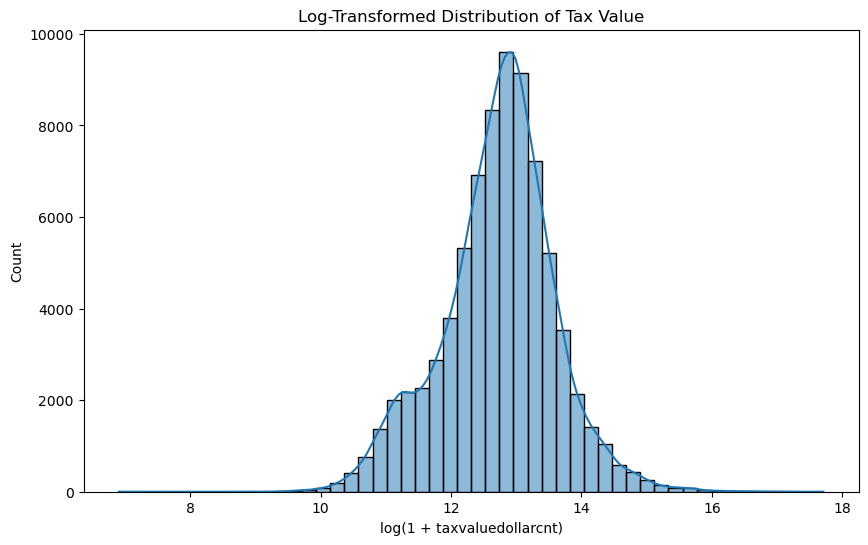
**Figure 1: Target Distribution (`taxvaluedollarcnt`) - Histogram + Boxplot**  
This plot shows a heavily right-skewed distribution with a long upper tail and extreme high-value outliers. It matters because it explains why absolute dollar errors can become large and why robust metrics and models are important.

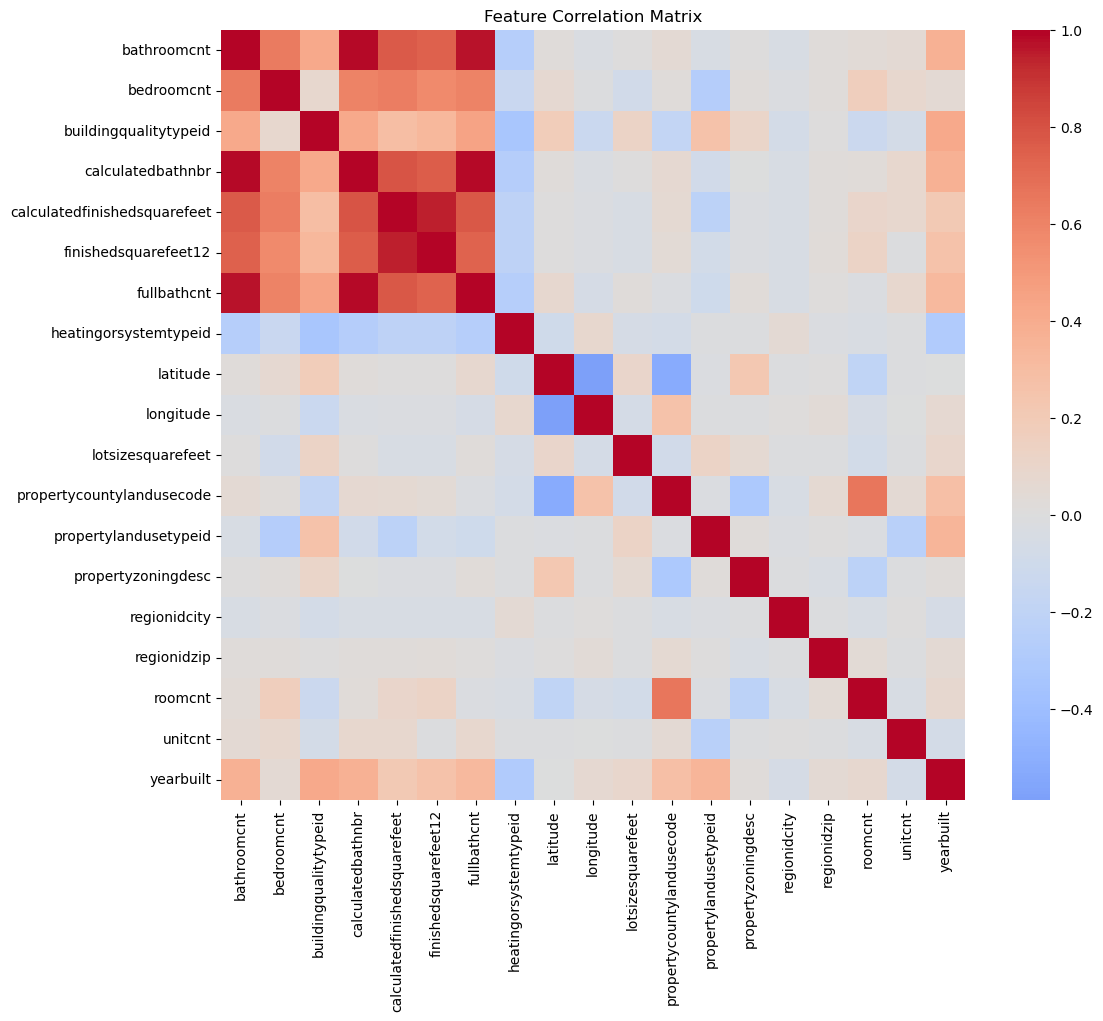

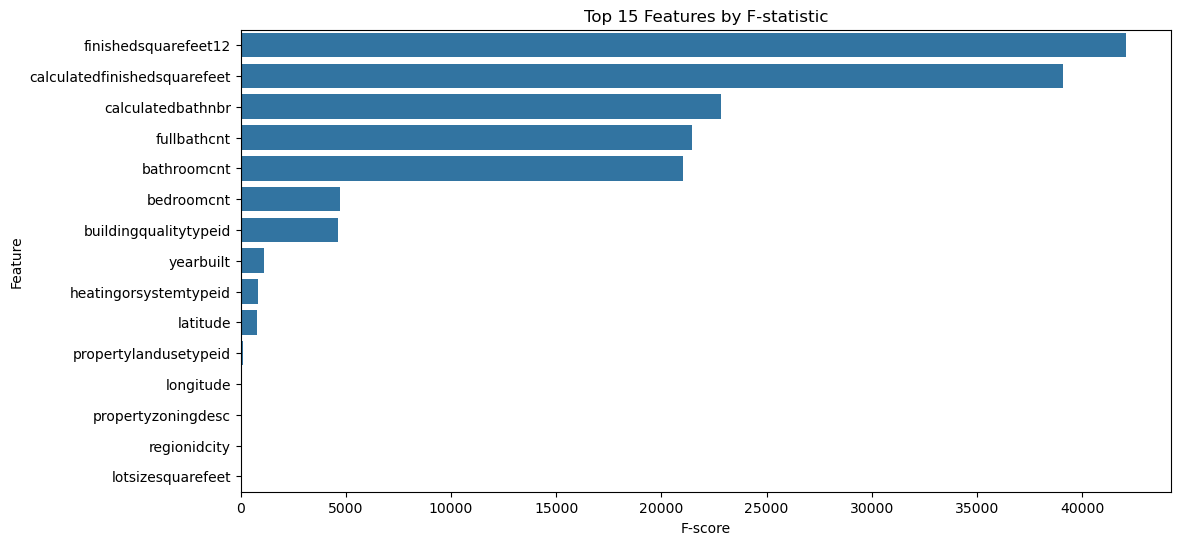


**Figure 2: Correlation/F-score Feature Importance Summary**  
This visualization highlights that size and location features (for example, `calculatedfinishedsquarefeet`, `finishedsquarefeet12`, latitude/longitude) are among the strongest predictors. It matters because it validates domain expectations and guides both feature engineering and feature selection decisions.

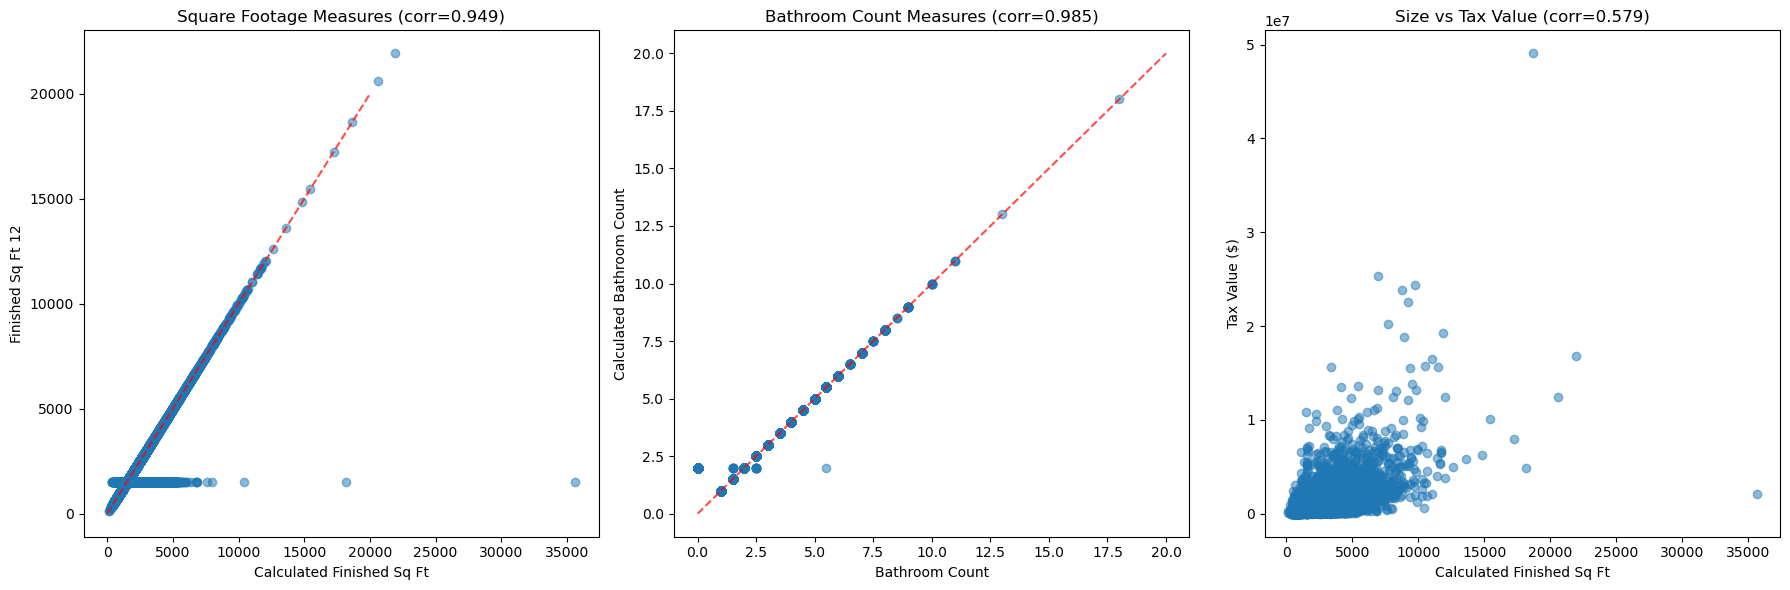
**Figure 3: Size vs. Value Scatter/Density Plot (`calculatedfinishedsquarefeet` vs `taxvaluedollarcnt`)**  
Screenshot used for Figure 3: Size vs Tax Value scatter/density plot from Milestone 1 (Part 4.B).
This plot shows a clear positive relationship, but with widening spread as property size and value increase. It matters because it reveals heteroscedasticity and indicates that errors are likely larger for expensive homes, which aligns with the residual behavior observed in final model evaluation.

Together, these visualizations provide evidence for three key claims: the target is difficult due to skew and outliers, size/location are dominant value drivers, and prediction uncertainty grows in the high-price segment.

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  
Error analysis showed several consistent patterns:

1. **Regression-to-the-mean behavior**  
The model tends to overpredict lower-value properties and underpredict very high-value properties. This is common in real estate regression when the target has a long right tail.

2. **Larger errors for expensive homes**  
Residual spread increases with property value, indicating heteroscedasticity. In practical terms, predictions are more reliable in the middle of the market and less reliable for luxury properties.

3. **Outlier sensitivity**  
A small number of multi-million-dollar homes create disproportionately large residuals and increase RMSE. These observations are valid records, so they were retained, but they remain a key source of error.

4. **Model-level bias/variance trade-off**  
Random Forest achieved the best test performance, but the train-test gap suggests moderate overfitting. Linear models were more stable but less accurate overall.

Most surprising finding:
- Manual feature engineering substantially helped linear models but provided limited benefit for Random Forest, reinforcing that tree ensembles already capture nonlinear effects and interactions.

Priority improvements:
- Add richer external location context (school quality, transit access, neighborhood amenities).
- Test target-transform strategies (for example, modeling on log-value and inverse-transforming carefully).
- Explore robust/stacked ensembles to reduce extreme-value error while preserving overall MAE performance.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
This project’s objective was to build and evaluate a reproducible machine learning pipeline for predicting residential tax-assessed property values in Los Angeles County. We met that objective by completing end-to-end cleaning, feature engineering, model comparison, and tuning, then selecting a final production candidate.

The main finding is that **Random Forest** provided the best predictive performance among tested models, with about **$189,956.93 CV MAE** and **test $R^2 = 0.5649**. This outcome confirms that nonlinear ensemble methods are better suited than simple linear models for this dataset’s structure. We also found that size and location are the dominant predictors, and that engineered nonlinear features are especially useful for linear models.

Business implications:
- The model is strong enough to support automated first-pass valuation, anomaly flagging, and analyst prioritization.
- It can improve consistency and speed compared with manual-only approaches.
- It should be positioned as a decision-support tool rather than a replacement for full appraisal, especially for luxury homes.

Limitations:
- Strong right skew and high-value outliers increase prediction error.
- Some potentially informative fields were dropped due to high missingness.
- We used primarily internal property attributes; external neighborhood context was limited.

Future improvements:
- Add external geospatial and neighborhood features.
- Test stronger ensembling/stacking and robust error objectives.
- Calibrate predictions by price segment to reduce bias at distribution extremes.

Final recommendation: deploy the tuned Random Forest model as the baseline AVM for internal valuation workflows, with a confidence/exception layer that routes high-value or high-uncertainty properties to manual review.